<a href="https://colab.research.google.com/github/RahulSwami151/Autonomous-Data-Science-Copilot/blob/main/Autonomous_DataScience_Copilot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 Autonomous Data Science Co-Pilot

**Summer Internship Project — Agentic AI / Data Engineering / Full-Stack Python**

An AI agent that behaves like a junior data analyst:
1. You upload a CSV / Excel / JSON file and ask a question in plain English.
2. The agent **writes Python/Pandas code on its own**.
3. The code runs in a **restricted sandbox**.
4. If it errors, the agent does **live RAG over official Python & Pandas docs** to fix itself, and retries.
5. It keeps going until it produces a working chart + a plain-English insight.

This notebook is the **research/prototyping environment**. The paired `app.py` (Streamlit)
is the deployable web UI — built independently, so you can hand the notebook to reviewers
and the app to end users without one depending on the other.


In [1]:
# Cell 2 — Install dependencies
# openai        -> the LLM that writes/fixes code (swap for anthropic/google-generativeai if you prefer)
# pandas/numpy  -> data manipulation
# matplotlib/seaborn -> charts
# openpyxl      -> lets pandas read .xlsx files
# beautifulsoup4 + requests -> used to LIVE fetch official docs pages for RAG self-healing
# scikit-learn  -> lightweight TF-IDF reranker so RAG returns the *most relevant* doc chunk, not the whole page

!pip -q install openai pandas numpy matplotlib seaborn openpyxl beautifulsoup4 requests scikit-learn
print("✅ Dependencies installed")

✅ Dependencies installed


In [21]:
# Cell 3 — Imports & configuration
import io, os, sys, json, traceback, contextlib, textwrap
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")   # headless rendering — we save/show figures manually
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from getpass import getpass
from openai import OpenAI

# --- Free LLM via OpenRouter ---
# OpenRouter is OpenAI-SDK-compatible: same client, just a different base_url + key.
# Sign up free (no card needed) at https://openrouter.ai -> Settings -> API Keys.
if "OPENROUTER_API_KEY" not in os.environ:
    os.environ["OPENROUTER_API_KEY"] = getpass("Enter your OpenRouter API key: ")

client = OpenAI(
    api_key=os.environ["OPENROUTER_API_KEY"],
    base_url="https://openrouter.ai/api/v1",
)

# "openrouter/free" auto-routes to whatever free model is currently available —
# more robust than hardcoding a model ID, since OpenRouter's free lineup rotates.
# To pin a specific free model instead, swap in e.g. "meta-llama/llama-3.3-70b-instruct:free"
# or "qwen/qwen3-coder:free" (good for code generation).
LLM_MODEL = "openrouter/free"
MAX_SELF_HEAL_RETRIES = 4

print("✅ Config ready (using OpenRouter free tier)")

Enter your OpenRouter API key: ··········
✅ Config ready (using OpenRouter free tier)


In [10]:
# Cell 4 — Upload a file and load it into a DataFrame (CSV / Excel / JSON)
from google.colab import files

def load_any_file(path: str) -> pd.DataFrame:
    ext = path.lower().split(".")[-1]
    if ext == "csv":
        return pd.read_csv(path)
    elif ext in ("xlsx", "xls"):
        return pd.read_excel(path)
    elif ext == "json":
        return pd.read_json(path)
    else:
        raise ValueError(f"Unsupported file type: .{ext}. Use CSV, Excel, or JSON.")

uploaded = files.upload()               # opens a file picker in Colab
FILE_PATH = list(uploaded.keys())[0]
df = load_any_file('/content/Sales.csv')
print(f"✅ Loaded '{'/content/Sales.csv'}' — shape: {df.shape}")
df.head()

Saving Sales_January_2019.csv to Sales_January_2019.csv
✅ Loaded '/content/Sales.csv' — shape: (9723, 6)


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,141234,iPhone,1,700,01/22/19 21:25,"944 Walnut St, Boston, MA 02215"
1,141235,Lightning Charging Cable,1,14.95,01/28/19 14:15,"185 Maple St, Portland, OR 97035"
2,141236,Wired Headphones,2,11.99,01/17/19 13:33,"538 Adams St, San Francisco, CA 94016"
3,141237,27in FHD Monitor,1,149.99,01/05/19 20:33,"738 10th St, Los Angeles, CA 90001"
4,141238,Wired Headphones,1,11.99,01/25/19 11:59,"387 10th St, Austin, TX 73301"


In [12]:
# Cell 5 — Profile the dataset so the LLM understands the schema before writing code
def profile_dataframe(df: pd.DataFrame) -> str:
    """Builds a compact text summary (columns, dtypes, nulls, sample rows) to feed the LLM as context.
    We never send the *whole* dataset to the LLM — just its shape — for both cost and privacy reasons."""

    buf = io.StringIO()
    df.info(buf=buf)
    schema_info = buf.getvalue()

    profile = f"""
Shape: {df.shape[0]} rows x {df.shape[1]} columns

Columns and dtypes:
{schema_info}

Missing values per column:
{df.isnull().sum().to_string()}

First 5 rows:
{df.head().to_string()}
"""
    return profile

DATA_PROFILE = profile_dataframe(df)
print(DATA_PROFILE)


Shape: 9723 rows x 6 columns

Columns and dtypes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9723 entries, 0 to 9722
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Order ID          9697 non-null   object
 1   Product           9697 non-null   object
 2   Quantity Ordered  9697 non-null   object
 3   Price Each        9697 non-null   object
 4   Order Date        9697 non-null   object
 5   Purchase Address  9697 non-null   object
dtypes: object(6)
memory usage: 455.9+ KB


Missing values per column:
Order ID            26
Product             26
Quantity Ordered    26
Price Each          26
Order Date          26
Purchase Address    26

First 5 rows:
  Order ID                   Product Quantity Ordered Price Each      Order Date                       Purchase Address
0   141234                    iPhone                1        700  01/22/19 21:25        944 Walnut St, Boston, MA 02215
1   141235 

In [13]:
# Cell 6 — Prompt templates for the code-writing agent
SYSTEM_PROMPT = """You are a senior data analyst AI. You write short, correct, self-contained Python code
that analyzes a pandas DataFrame called `df` which is already loaded in memory.

Rules:
- Only use pandas, numpy, matplotlib.pyplot (as plt), and seaborn (as sns).
- Never read/write files and never re-load `df` — it already exists.
- If you produce a chart, create it on a variable named `fig` (e.g. fig, ax = plt.subplots()) and do NOT call plt.show().
- Store any text findings in a variable named `insight_text` (a plain-English string).
- Return ONLY a Python code block — no explanations outside the code.
"""

def build_generation_prompt(question: str, data_profile: str) -> str:
    return f"""Dataset profile:
{data_profile}

User question: \"{question}\"

Write Python code that answers this using the `df` DataFrame already in memory.
Produce a matplotlib/seaborn chart in `fig` where relevant, and always set `insight_text`
to a 2-4 sentence plain-English summary of what the data shows."""

def build_fix_prompt(question: str, data_profile: str, previous_code: str, error_message: str, doc_context: str) -> str:
    return f"""The following code failed.

Dataset profile:
{data_profile}

User question: \"{question}\"

Previous code:
```python
{previous_code}
```

Error raised:
{error_message}

Relevant excerpt from official Python/Pandas documentation (use this to fix the bug):
{doc_context}

Rewrite the FULL corrected code from scratch (same rules: use existing `df`, put chart in `fig`,
put summary text in `insight_text`). Return ONLY the corrected Python code."""

print("✅ Prompt templates ready")

✅ Prompt templates ready


In [14]:
# Cell 7 — Ask the LLM to write (or fix) the analysis code
def extract_code_block(text: str) -> str:
    """Strips markdown ```python fences if the model adds them."""
    text = text.strip()
    if "```" in text:
        parts = text.split("```")
        for p in parts:
            if p.strip().startswith("python"):
                return p.strip()[len("python"):].strip()
        return parts[1].strip() if len(parts) > 1 else text
    return text

def call_llm_for_code(prompt: str) -> str:
    response = client.chat.completions.create(
        model=LLM_MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": prompt},
        ],
        temperature=0.2,
    )
    return extract_code_block(response.choices[0].message.content)

print("✅ Code-generation function ready")

✅ Code-generation function ready


In [15]:
# Cell 8 — Restricted sandbox executor
# We don't shell out to a subprocess here (Colab-friendly + faster), but we DO restrict the
# execution namespace to only what's needed, and capture stdout + exceptions cleanly.

SAFE_BUILTINS = {
    "range": range, "len": len, "min": min, "max": max, "sum": sum, "sorted": sorted,
    "list": list, "dict": dict, "set": set, "tuple": tuple, "str": str, "int": int,
    "float": float, "bool": bool, "enumerate": enumerate, "zip": zip, "round": round,
    "print": print, "abs": abs,
}

def safe_exec(code_str: str, df: pd.DataFrame):
    """Executes generated code in a restricted namespace.
    Returns (success: bool, result_dict, error_message: str)"""
    local_ns = {"df": df, "pd": pd, "np": np, "plt": plt, "sns": sns}
    global_ns = {"__builtins__": SAFE_BUILTINS}

    stdout_capture = io.StringIO()
    try:
        with contextlib.redirect_stdout(stdout_capture):
            exec(code_str, global_ns, local_ns)
        return True, {
            "fig": local_ns.get("fig"),
            "insight_text": local_ns.get("insight_text", ""),
            "stdout": stdout_capture.getvalue(),
        }, ""
    except Exception:
        return False, {}, traceback.format_exc(limit=3)

print("✅ Sandbox executor ready")

✅ Sandbox executor ready


In [17]:
# Cell 9 — RAG self-healing: live web search over official Python/Pandas docs
# Strategy: on error, (1) search the web restricted to docs.python.org / pandas.pydata.org,
# (2) fetch the top page(s), (3) split into chunks, (4) TF-IDF-rank chunks against the error
# message so the LLM gets the *most relevant* snippet rather than a whole page (this reranking
# step is what makes it "RAG" rather than a raw search dump).

TRUSTED_DOC_SITES = ["pandas.pydata.org", "docs.python.org"]

def web_search_docs(query: str, max_results: int = 5):
    """Live search via DuckDuckGo's HTML endpoint (no API key needed)."""
    resp = requests.get(
        "https://html.duckduckgo.com/html/",
        params={"q": query},
        headers={"User-Agent": "Mozilla/5.0"},
        timeout=10,
    )
    soup = BeautifulSoup(resp.text, "html.parser")
    links = []
    for a in soup.select("a.result__a"):
        href = a.get("href", "")
        if any(site in href for site in TRUSTED_DOC_SITES):
            links.append(href)
        if len(links) >= max_results:
            break
    return links

def fetch_page_text(url: str) -> str:
    try:
        resp = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=10)
        soup = BeautifulSoup(resp.text, "html.parser")
        for tag in soup(["script", "style", "nav", "footer"]):
            tag.decompose()
        return soup.get_text(separator=" ", strip=True)
    except Exception:
        return ""

def chunk_text(text: str, chunk_size: int = 400):
    words = text.split()
    return [" ".join(words[i:i + chunk_size]) for i in range(0, len(words), chunk_size)]

def rerank_chunks(error_message: str, chunks: list, top_k: int = 1) -> str:
    """TF-IDF + cosine similarity — a lightweight local retrieval/rerank step (no vector DB needed
    since we're pulling docs live rather than from a prebuilt corpus)."""
    if not chunks:
        return ""
    vectorizer = TfidfVectorizer(stop_words="english")
    matrix = vectorizer.fit_transform(chunks + [error_message])
    sims = cosine_similarity(matrix[-1], matrix[:-1]).flatten()
    top_idx = sims.argsort()[::-1][:top_k]
    return "\n---\n".join(chunks[i] for i in top_idx)

def fetch_relevant_docs(error_message: str) -> str:
    """Full RAG retrieval step, called only when execution fails."""
    # Use the exception type/last line as the search query — it's the most searchable signal
    query = error_message.strip().splitlines()[-1] if error_message.strip() else "pandas error"
    query = f"{query} pandas python site:pandas.pydata.org OR site:docs.python.org"
    urls = web_search_docs(query)
    all_chunks = []
    for url in urls[:3]:
        text = fetch_page_text(url)
        all_chunks.extend(chunk_text(text))
    return rerank_chunks(error_message, all_chunks, top_k=2)

print("✅ RAG retrieval pipeline ready")

✅ RAG retrieval pipeline ready


In [18]:
# Cell 10 — The self-healing agent loop (generate -> execute -> retry with RAG-fixed code)
def autonomous_analyze(df: pd.DataFrame, question: str, data_profile: str, max_retries: int = MAX_SELF_HEAL_RETRIES):
    """Returns a dict with: success, code, result, attempts, heal_log"""
    heal_log = []
    code_str = call_llm_for_code(build_generation_prompt(question, data_profile))

    for attempt in range(1, max_retries + 1):
        success, result, error = safe_exec(code_str, df)
        if success:
            heal_log.append(f"Attempt {attempt}: ✅ succeeded")
            return {"success": True, "code": code_str, "result": result, "attempts": attempt, "heal_log": heal_log}

        heal_log.append(f"Attempt {attempt}: ❌ {error.strip().splitlines()[-1]}")
        doc_context = fetch_relevant_docs(error)
        heal_log.append(f"   ↳ RAG fetched doc context ({len(doc_context)} chars) to self-correct")
        code_str = call_llm_for_code(
            build_fix_prompt(question, data_profile, code_str, error, doc_context)
        )

    return {"success": False, "code": code_str, "result": {}, "attempts": max_retries, "heal_log": heal_log}

print("✅ Self-healing loop ready")

✅ Self-healing loop ready


In [19]:
# Cell 11 — Run the pipeline end-to-end and display chart + insight
def run_copilot(df: pd.DataFrame, question: str):
    profile = profile_dataframe(df)
    outcome = autonomous_analyze(df, question, profile)

    print("🔧 Self-healing log:")
    for line in outcome["heal_log"]:
        print(" ", line)

    if not outcome["success"]:
        print("\n❌ Could not produce a working result after", outcome["attempts"], "attempts.")
        return outcome

    result = outcome["result"]
    if result.get("fig") is not None:
        display(result["fig"])
    if result.get("insight_text"):
        print("\n💡 Insight:", result["insight_text"])
    if result.get("stdout"):
        print("\n📄 Output:\n", result["stdout"])

    print("\n🧾 Generated code (for transparency / audit):")
    print(outcome["code"])
    return outcome

print("✅ Pipeline wrapper ready — call run_copilot(df, 'your question') to try it")

✅ Pipeline wrapper ready — call run_copilot(df, 'your question') to try it


<string>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


🔧 Self-healing log:
  Attempt 1: ❌ ImportError: __import__ not found
     ↳ RAG fetched doc context (0 chars) to self-correct
  Attempt 2: ❌ ImportError: __import__ not found
     ↳ RAG fetched doc context (0 chars) to self-correct
  Attempt 3: ❌ ImportError: __import__ not found
     ↳ RAG fetched doc context (0 chars) to self-correct
  Attempt 4: ✅ succeeded


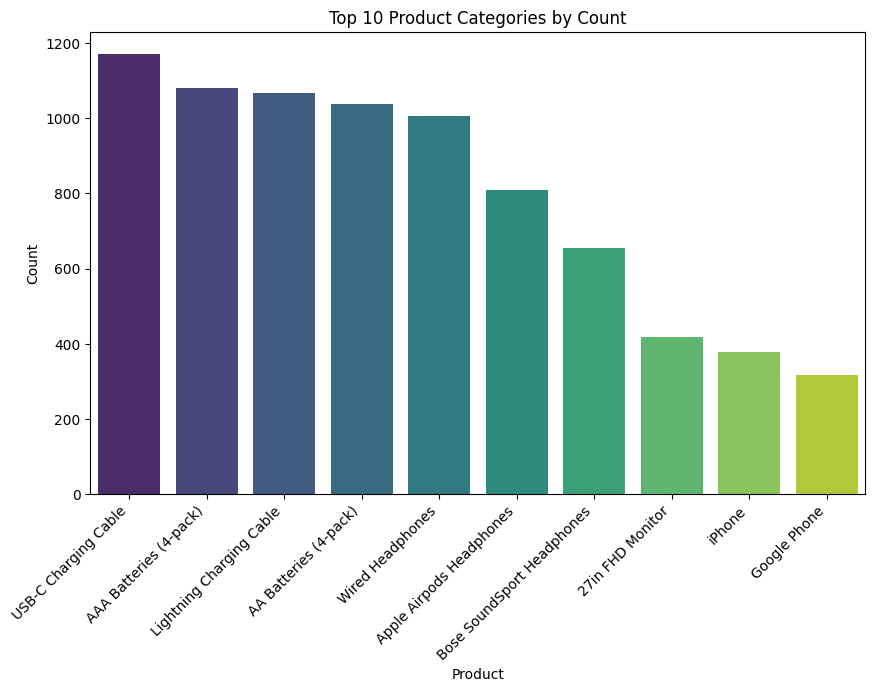


💡 Insight: The bar chart displays the frequency of the top ten product categories. The most frequent product is 'USB-C Charging Cable' with 1171 occurrences, followed by 'AAA Batteries (4-pack)' and 'Lightning Charging Cable' with 1082 and 1068 occurrences respectively. These results suggest that electronic accessories dominate the dataset.

🧾 Generated code (for transparency / audit):
product_counts = df['Product'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=product_counts.index, y=product_counts.values, ax=ax, palette='viridis')
ax.set_title('Top 10 Product Categories by Count')
ax.set_xlabel('Product')
ax.set_ylabel('Count')
ax.set_xticklabels(product_counts.index, rotation=45, ha='right')

insight_text = (
    f"The bar chart displays the frequency of the top ten product categories. "
    f"The most frequent product is '{product_counts.index[0]}' with {product_counts.iloc[0]} occurrences, "
    f"followed by '{product_counts.index[1]}' and '{produ

In [22]:
# Cell 12 — Try it on your uploaded data
# Examples matching the 5 use cases from the project brief:
#   "Show me a bar chart of revenue by region"          -> Sales Dashboard
#   "Are there any missing values or duplicate rows?"    -> Data Quality Audit
#   "Is the value in the amount column trending up over time?" -> Trend Analysis
#   "Segment customers into groups based on total spend" -> Cohort Analysis
#   "What's the average and median of each numeric column?" -> Ad-hoc Query

outcome = run_copilot(df, "Show me a bar chart of the top categories by count")